<a href="https://colab.research.google.com/github/VictorSu33/MAT1510/blob/main/MAT1510_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Measure over-squashing
> Add blockquote



In [ ]:
from typing import ValuesView
import torch
import torch.nn as nn
from torch.nn.functional import scaled_dot_product_attention
from typing import Callable, Optional

class SinusoidalPosEnc(nn.Module):
    def __init__(self, d_model: int, base: float = 10000.0):
        super().__init__()
        self.d_model = d_model
        self.base = base

    def forward(self, L: int, device=None, dtype=None):
        device = device or torch.device("cpu")
        dtype  = dtype  or torch.float32

        pos = torch.arange(L, dtype=torch.float32, device=device)[:, None]          # (L,1)
        i   = torch.arange(self.d_model, dtype=torch.float32, device=device)[None] # (1,D)

        # angles: (L,D)
        angles = pos / (self.base ** (2 * (i // 2) / self.d_model))

        pe = torch.empty((L, self.d_model), device=device, dtype=dtype)
        pe[:, 0::2] = torch.sin(angles[:, 0::2])
        pe[:, 1::2] = torch.cos(angles[:, 1::2])

        return pe.to(dtype)[None, :, :]

class LayerNorm(nn.Module):

  def __init__(self, eps: float = 1e-6):
    super().__init__()
    self.eps = eps

  def forward(self,v):
    mean = v.mean(-1, keepdim=True)
    std = v.std(-1, keepdim=True)
    return (v - mean) / (std + self.eps)

class TransformerLayer(nn.Module):
  def __init__(self, d_model):
    super().__init__()
    self.d_model = d_model
    self.LN = LayerNorm()
    self.ffn = nn.Linear(d_model, d_model)

    #resample query and key?

  def forward(self, v, q, k):
    assert v.shape == q.shape == k.shape

    h = self.LN(scaled_dot_product_attention(q,k,v, is_causal = True) + v)
    h = self.LN(self.ffn(h) + h)
    return h

class Transformer(nn.Module):

  def __init__(self, d_model, depth):
    super().__init__()
    self.d_model = d_model
    self.depth = depth

    self.PosEnc = SinusoidalPosEnc(d_model)

    self.layers = nn.ModuleList([TransformerLayer(d_model) for _ in range(depth)])

  def forward(self, v, q, k):

    L,_ = v.shape[-2:]
    for i, layer in enumerate(self.layers):
      v = layer(v, q[i], k[i])

    return v







In [ ]:
from torch.func import jacrev, vmap

def run_trials(d_model: int, depth: int, num_trials: int, L: int, device = 'cpu', dtype = torch.bfloat16):

  model = Transformer(d_model, depth)
  model.to(device=device, dtype=dtype)
  model.eval()

  v = torch.randn(
    num_trials, L, d_model,
    device=device, dtype=dtype,
    requires_grad=True
  )

  q = torch.randn(
      depth, num_trials, L, d_model,
      device=device, dtype=dtype
  )

  k = torch.randn_like(q)

  qT = q.permute(1, 0, 2, 3)
  kT = k.permute(1, 0, 2, 3)

  pe = model.PosEnc(L, device=v.device, dtype=v.dtype)  # (1,L,d)
  v_pe = v + pe  # (T,L,d)

  def f(v, q, k):
    return model(v, q, k)[-1:,:].squeeze(0)

  #want ~ ()
  J = vmap(jacrev(f))(v_pe, qT, kT)
  print("jacobian shape", J.shape)

  avg_norms = torch.norm(J, dim=(1,3)).mean(0)
  print("avg norms", avg_norms.shape)
  assert avg_norms.shape == (L,)

  return avg_norms


input depth and L to display graph:8 64
jacobian shape torch.Size([32, 64, 8, 64])
avg norms torch.Size([8])
ratio=1.6908948421478271
jacobian shape torch.Size([32, 64, 16, 64])
avg norms torch.Size([16])
ratio=1.3362616300582886
jacobian shape torch.Size([32, 64, 24, 64])
avg norms torch.Size([24])
ratio=1.2355122566223145
jacobian shape torch.Size([32, 64, 32, 64])
avg norms torch.Size([32])
ratio=1.166946291923523
jacobian shape torch.Size([32, 64, 40, 64])
avg norms torch.Size([40])
ratio=1.1361687183380127
jacobian shape torch.Size([32, 64, 48, 64])
avg norms torch.Size([48])
ratio=1.115177035331726
jacobian shape torch.Size([32, 64, 56, 64])
avg norms torch.Size([56])
ratio=1.1009666919708252
jacobian shape torch.Size([32, 64, 64, 64])
avg norms torch.Size([64])
ratio=1.0886175632476807
d_model=64, depth=8, L=64


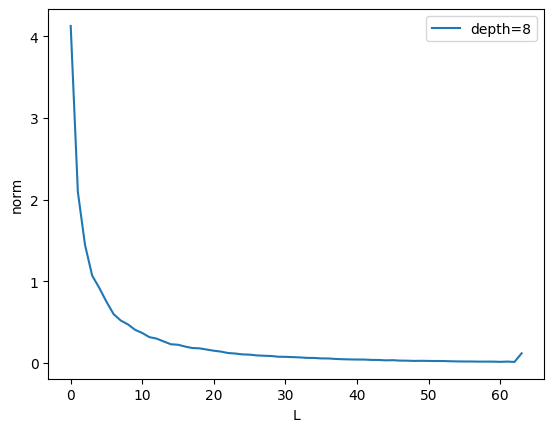

jacobian shape torch.Size([32, 64, 72, 64])
avg norms torch.Size([72])
ratio=1.0787912607192993


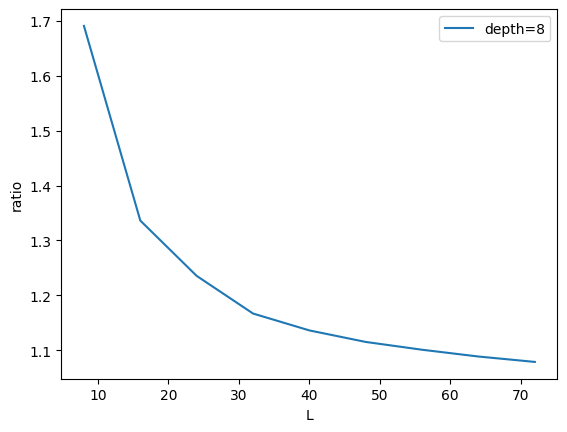

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

if __name__ == "__main__":
  d_model = 64
  depths = [2**k for k in range(1,4)]
  num_trials = 32
  Ls = [8*k for k in range(1,10)]
  device = torch.device("cpu")
  dtype = torch.bfloat16

  depth_, L_ = map(int, input("input depth and L to display graph:").split())
  assert depth_ in depths and L_ in Ls
  for depth in depths:
    if depth != depth_:
      continue
    ratios = []
    for L in Ls:
      norms = run_trials(d_model, depth, num_trials, L, device, dtype)
      norms = norms.detach().cpu().float().numpy()
      avg_ratio = np.mean([a / b for a, b in zip(norms, norms[1:])])
      print(f"ratio={avg_ratio}")

      if L == L_:

        print(f"d_model={d_model}, depth={depth}, L={L}")

        plt.plot(norms, label=f"depth={depth}")
        plt.xlabel("L")
        plt.ylabel("norm")

        plt.legend()
        plt.show()

      ratios.append(avg_ratio)
    plt.plot(Ls, ratios, label=f"depth={depth}")
    plt.xlabel("L")
    plt.ylabel("ratio")

    plt.legend()
    plt.show()


#can plot fixed length across depths or plot some length independent value across length like ratio of first to last

